<a href="https://colab.research.google.com/github/Kieunhungtruong/Econometrics/blob/main/pythonversion/chapter6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display:flex;flex-direction:column;align-items:center;justify-content:center;gap:10px;">
  <h1 style="text-align:center;font-size:26px;font-weight:bold;font-family:'Nunito';color:purple;">
    Chapter 6 – Hồi quy Danh nghĩa Đa biến (Multinomial Logit Model)
  </h1>
</div>

## Kết nối Google Drive và cài gói cần thiết

In [1]:
from google.colab import drive
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [2]:
!pip install pyreadstat statsmodels -q

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import chi2
import pyreadstat
import warnings
warnings.filterwarnings('ignore')

palette = ["#53b0ae", "#a31414", "#2b6999", "#e37000", "#b2c615", "#88837d", "#B3B3B3"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.9 MB/s eta 0:00:00


## Đọc dữ liệu

In [3]:
df, meta = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/migration.dta",
    encoding="latin1",
)
df.head()

,tinh,huyen,xa,diaban,hoso,m1ama,HHsize,gender,genderhead,age,agehead,agehead2,children_ratio,elderly_ratio,migration_place,urban,ethnicity,agrland,house_structure
0,1,1,7,6,1,1,5.0,0.0,0.0,59.0,59.0,3481.0,0.4,0.0,0.0,1.0,1.0,0.0,1.0
1,1,1,7,6,1,2,5.0,1.0,0.0,45.0,59.0,3481.0,0.4,0.0,0.0,1.0,1.0,0.0,1.0
2,1,1,7,6,1,3,5.0,0.0,0.0,15.0,59.0,3481.0,0.4,0.0,0.0,1.0,1.0,0.0,1.0
3,1,1,7,6,2,1,3.0,0.0,0.0,50.0,50.0,2500.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,1,1,7,6,2,2,3.0,1.0,0.0,50.0,50.0,2500.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0


---
# 6.1 Giới thiệu – Mô hình hồi quy danh nghĩa đa biến

Trong chương trước chúng ta xem xét các mô hình khi biến phụ thuộc chỉ nhận hai giá trị, ví dụ như hút thuốc hay không hút thuốc. Mô hình đó gọi là **mô hình hồi quy nhị phân** (binary regression model).

Tuy nhiên, trong thực tế nhiều lựa chọn có **nhiều hơn hai phương án riêng biệt** (several discrete alternatives). Trong trường hợp này, mô hình được sử dụng để ước lượng là **mô hình hồi quy danh nghĩa đa biến** (multinomial regression models: MRM), với giả định rằng các lựa chọn không có liên quan gì với nhau (independence of irrelevant alternatives: **IIA**).

Một số ví dụ điển hình có thể dùng mô hình này:
- Lựa chọn phương tiện di chuyển: xe hơi, bus, tàu điện, xe đạp.
- Lựa chọn tôn giáo: Tin lành, Do thái, Hồi giáo, Phật giáo.
- Lựa chọn giáo dục: trung học, đại học, sau đại học.
- Lựa chọn công việc: không làm việc, làm bán thời gian, làm toàn thời gian.

Có hai kiểu MRM:
1. **MRM không có thứ tự** (unordered): Ví dụ lựa chọn phương tiện giao thông – không có một thứ tự cụ thể nào giữa các lựa chọn.
2. **MRM có thứ tự** (ordered): Ví dụ mức độ đồng ý – hoàn toàn đồng ý, đồng ý phần nào, không đồng ý.

---
# 6.2 Hồi quy Logit Đa biến (MLM)

**Hồi quy logit đa biến** (Multinomial Logit Model: MLM) và hồi quy probit đa biến (MPM) thích hợp khi các biến giải thích thay đổi giữa các cá nhân (vary across individuals).

Trong MLM, ta chọn một phương án làm **cơ sở so sánh** (base category) và đặt các hệ số hồi quy của nó bằng 0. Với 3 phương án (ký hiệu 1, 2, 3), mô hình logit tổng quát hóa như sau:

$$\pi_{i1} = \frac{1}{1 + e^{(\alpha_2 + \beta_2 X_i)} + e^{(\alpha_3 + \beta_3 X_i)}}$$

$$\pi_{i2} = \frac{e^{(\alpha_2 + \beta_2 X_i)}}{1 + e^{(\alpha_2 + \beta_2 X_i)} + e^{(\alpha_3 + \beta_3 X_i)}}$$

$$\pi_{i3} = \frac{e^{(\alpha_3 + \beta_3 X_i)}}{1 + e^{(\alpha_2 + \beta_2 X_i)} + e^{(\alpha_3 + \beta_3 X_i)}}$$

Lấy log tỷ lệ odd (odds ratios) và ước lượng đồng thời bằng **xác suất cực đại** (maximum likelihood: ML):

$$\ln\left(\frac{\pi_{i2}}{\pi_{i1}}\right) = \alpha_2 + \beta_2 X_i$$

$$\ln\left(\frac{\pi_{i3}}{\pi_{i1}}\right) = \alpha_3 + \beta_3 X_i$$

$$\pi_{i1} = 1 - \pi_{i2} - \pi_{i3}$$

## Ví dụ: Lựa chọn nơi di cư để làm việc

Chúng ta xem xét việc lựa chọn di cư làm việc của một cá nhân. Dữ liệu **VHLSS 2018** bao gồm **47,044 cá nhân** trong độ tuổi lao động, trong đó có 347 cá nhân di cư vì mục đích tìm kiếm việc làm.

Biến phụ thuộc `migration_place` được mã hoá:
- `0`: Không di cư hoặc di cư vì các lý do khác (**nhóm tham chiếu**)
- `1`: Di cư đến Hà Nội / Hồ Chí Minh để làm việc
- `2`: Di cư đến các tỉnh khác để làm việc
- `3`: Di cư ra nước ngoài để làm việc

Với 4 phương án và nhóm tham chiếu là `migration_place = 0`, mô hình xác suất trở thành:

$$\pi_{i1} = \frac{1}{1+e^{(\alpha_2+\beta_2 X_i)}+e^{(\alpha_3+\beta_3 X_i)}+e^{(\alpha_4+\beta_4 X_i)}}$$

$$\ln\left(\frac{\pi_{i2}}{\pi_{i1}}\right) = \alpha_2 + \beta_2 X_i \quad (6.11)$$

$$\ln\left(\frac{\pi_{i3}}{\pi_{i1}}\right) = \alpha_3 + \beta_3 X_i \quad (6.12)$$

$$\ln\left(\frac{\pi_{i4}}{\pi_{i1}}\right) = \alpha_4 + \beta_4 X_i \quad (6.13)$$

### Phân phối biến phụ thuộc

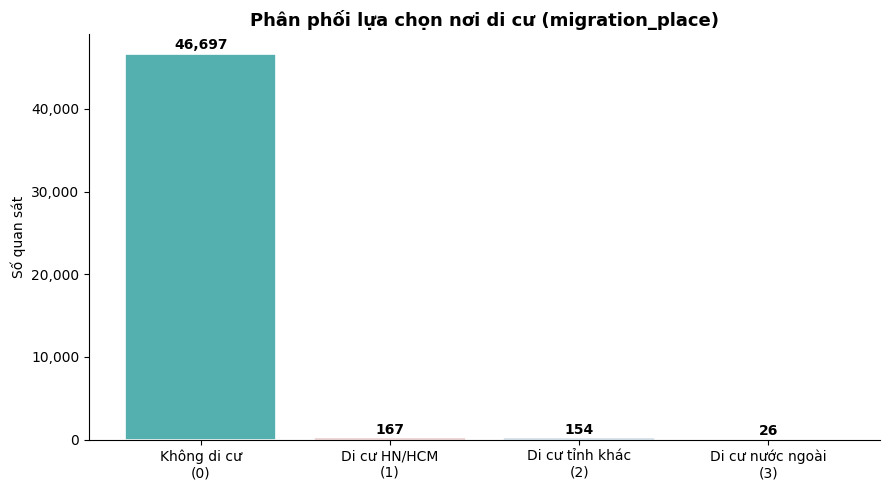


Phân phối chi tiết:
migration_place
Không di cư         46697
Di cư HN/HCM          167
Di cư tỉnh khác       154
Di cư nước ngoài       26
Name: count, dtype: int64


In [4]:
# Phân phối migration_place
counts = df['migration_place'].value_counts().sort_index()
labels = [
    'Không di cư\n(0)',
    'Di cư HN/HCM\n(1)',
    'Di cư tỉnh khác\n(2)',
    'Di cư nước ngoài\n(3)'
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, counts.values, color=palette[:4], edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Phân phối lựa chọn nơi di cư (migration_place)', fontsize=13, fontweight='bold')
ax.set_ylabel('Số quan sát')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print("\nPhân phối chi tiết:")
print(counts.rename({0:'Không di cư',1:'Di cư HN/HCM',2:'Di cư tỉnh khác',3:'Di cư nước ngoài'}))

---
## 6.2.1 Ước lượng mô hình MLM – Hệ số hồi quy (Bảng 6.1)

Chúng ta ước lượng mô hình MLM với biến phụ thuộc `migration_place` và các biến độc lập: giới tính (`gender`), tuổi (`age`), quy mô hộ (`HHsize`), giới tính chủ hộ (`genderhead`), tuổi chủ hộ (`agehead`), bình phương tuổi chủ hộ (`agehead2`), tỷ lệ trẻ em (`children_ratio`), tỷ lệ người già (`elderly_ratio`), khu vực (`urban`), dân tộc (`ethnicity`), đất nông nghiệp (`agrland`), và chất lượng nhà ở (`house_structure`).

Nhóm tham chiếu là `migration_place = 0` (không di cư hoặc di cư vì lý do khác).

In [5]:
from statsmodels.discrete.discrete_model import MNLogit

# Chuẩn bị biến
indep_vars = [
    'gender', 'age', 'HHsize', 'genderhead', 'agehead', 'agehead2',
    'children_ratio', 'elderly_ratio', 'urban', 'ethnicity', 'agrland', 'house_structure'
]

df_model = df.dropna(subset=['migration_place'] + indep_vars).copy()

X = sm.add_constant(df_model[indep_vars])
y = df_model['migration_place']

# Ước lượng mô hình MLM
model = MNLogit(y, X)
result = model.fit(method='newton', maxiter=200, disp=False)

print(result.summary())

                          MNLogit Regression Results                          
Dep. Variable:        migration_place   No. Observations:                47044
Model:                        MNLogit   Df Residuals:                    47005
Method:                           MLE   Df Model:                           36
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.1399
Time:                        10:39:14   Log-Likelihood:                -2033.1
converged:                       True   LL-Null:                       -2363.9
Covariance Type:            nonrobust   LLR p-value:                4.280e-116
migration_place=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -12.0823      2.152     -5.615      0.000     -16.300      -7.865
gender                0.2236      0.159      1.411      0.158      -0.087       0.534
age                  -0.

### Diễn giải kết quả – Hệ số hồi quy (Bảng 6.1)

Ước lượng của các biến độc lập dựa trên **nhóm tham chiếu `migration_place = 0`**:

- **Kết quả 1** (outcome 1): thể hiện tác động của các biến độc lập đến xác suất chọn **di cư đến HN/HCM** (migration_place = 1) so với **không di cư** (migration_place = 0), tương ứng phương trình 6.11.
- **Kết quả 2** (outcome 2): tác động đến xác suất chọn **di cư tỉnh khác** (migration_place = 2) so với nhóm tham chiếu.
- **Kết quả 3** (outcome 3): tác động đến xác suất chọn **di cư nước ngoài** (migration_place = 3) so với nhóm tham chiếu.

**Kiểm định độ phù hợp mô hình (Likelihood Ratio – LR):**
- LR chi2(36) = 661.64, p-value = 0.000 → **bác bỏ H₀** rằng tất cả hệ số dốc đều bằng 0.
- **Pseudo R²** (McFadden) = 0.1399. Lưu ý: Pseudo R² không có cùng ý nghĩa với R² trong hồi quy bội và được tính theo công thức:

$$\text{Pseudo } R^2 = 1 - \frac{\ln L_{fit}}{\ln L_0}$$

trong đó $L_{fit}$ là tỷ lệ hợp lý của mô hình đầy đủ và $L_0$ là tỷ lệ hợp lý của mô hình không có biến độc lập.

**Ý nghĩa thống kê theo từng kết quả:**
- *Kết quả 1*: `age`, `HHsize`, `agehead`, `agehead2`, `ethnicity`, `agrland`, `house_structure` có ý nghĩa ở mức 0.01; `children_ratio` có ý nghĩa ở mức 0.1.
- *Kết quả 2*: `age`, `HHsize`, `agehead`, `children_ratio`, `urban` có ý nghĩa ở mức 0.01; `genderhead`, `agehead2`, `elderly_ratio`, `house_structure` có ý nghĩa ở mức 0.1.
- *Kết quả 3*: `age`, `HHsize` có ý nghĩa ở mức 0.01; `agehead`, `agehead2`, `ethnicity`, `agrland`, `house_structure` có ý nghĩa ở mức 0.1.

---
## 6.2.2 Tỷ số rủi ro tương đối – Relative Risk Ratio (Bảng 6.2)

Để diễn giải trực quan hơn, ta chuyển **log-odds** về **tỷ số rủi ro tương đối** (Relative Risk Ratio: RRR) bằng cách lấy anti-log của hệ số hồi quy:

$$\text{RRR} = e^{\hat{\beta}}$$

Cách diễn giải RRR:
- Nếu log-odds **dương** → RRR > 1: biến làm **tăng** xác suất chọn phương án đó so với nhóm tham chiếu.
- Nếu log-odds **âm** → RRR < 1: biến làm **giảm** xác suất chọn phương án đó so với nhóm tham chiếu.

Ví dụ: Biến `agehead` (Kết quả 1) có hệ số = 0.351371:
$$\text{RRR}_{agehead} = e^{0.351371} = 1.421$$
Nghĩa là khi chủ hộ **tăng thêm 1 tuổi**, tỷ số odds của cá nhân chọn di cư đến HN/HCM so với không di cư **gấp 1.421 lần**, giữ nguyên các biến khác.

In [6]:
# Tính RRR = exp(coefficient)
params = result.params   # shape: (n_vars, n_outcomes)
rrr    = np.exp(params)

outcome_labels = ['Di cư HN/HCM (1)', 'Di cư tỉnh khác (2)', 'Di cư nước ngoài (3)']

rrr_df = pd.DataFrame(
    rrr.values,
    index=params.index,
    columns=outcome_labels
)

print("Bảng 6.2 – Tỷ số rủi ro tương đối (RRR)")
print("=" * 65)
print(rrr_df.round(4).to_string())

Bảng 6.2 – Tỷ số rủi ro tương đối (RRR)
                 Di cư HN/HCM (1)  Di cư tỉnh khác (2)  Di cư nước ngoài (3)
const                      0.0000               0.0009                1.3472
gender                     1.2506               1.0207                1.3730
age                        0.8907               0.8991                0.9071
HHsize                     0.6453               0.7419                0.5190
genderhead                 0.8048               0.6313                1.2435
agehead                    1.4210               1.1782                0.8269
agehead2                   0.9972               0.9991                1.0017
children_ratio             3.3640               7.0517                0.9398
elderly_ratio              0.5418               0.2133                0.6989
urban                      0.9338               0.4943                0.2924
ethnicity                  2.3997               0.9291                4.4422
agrland                    1.9250   

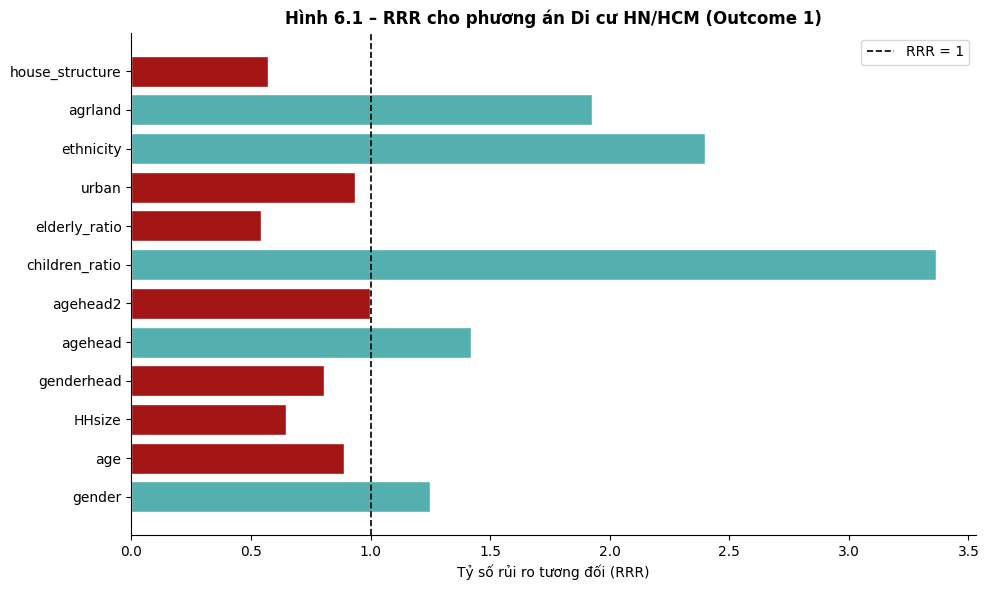

In [7]:
# Trực quan hóa RRR cho từng biến (outcome 1 – Di cư HN/HCM)
rrr_out1 = rrr_df[outcome_labels[0]].drop('const')

colors = [palette[0] if v >= 1 else palette[1] for v in rrr_out1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rrr_out1.index, rrr_out1.values, color=colors, edgecolor='white')
ax.axvline(x=1, color='black', linestyle='--', linewidth=1.2, label='RRR = 1')
ax.set_xlabel('Tỷ số rủi ro tương đối (RRR)')
ax.set_title('Hình 6.1 – RRR cho phương án Di cư HN/HCM (Outcome 1)', fontsize=12, fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 6.2.3 Dự đoán xác suất theo đặc điểm cá nhân (Bảng 6.3)

Dựa vào các ước lượng hồi quy, chúng ta có thể **dự đoán xác suất** chọn từng phương án cho một cá nhân có đặc điểm cụ thể.

### Quan sát thứ 10 trong dữ liệu
Cá nhân này có đặc điểm: nữ, 22 tuổi, hộ 4 thành viên, chủ hộ là nam, chủ hộ 52 tuổi, không có trẻ em, có 2 người già (elderly_ratio = 0.5), sống ở thành thị, dân tộc Kinh/Hoa, không có đất nông nghiệp, nhà ở kiên cố.

In [8]:
# Hàm dự đoán xác suất theo kiểu Stata "margins, at()"
# Thay thế biến được chỉ định, giữ nguyên các biến còn lại tại giá trị quan sát thực,
# sau đó lấy trung bình xác suất dự đoán trên toàn bộ mẫu.
def predict_margins_at(result, at_dict, df_model, var_order):
    df_at = df_model[var_order].copy()
    for var, val in at_dict.items():
        df_at[var] = val
    # Dùng numpy array thay vì DataFrame để tránh lỗi column index
    X_at = np.column_stack([np.ones(len(df_at)), df_at[var_order].values])
    probs = result.predict(X_at)  # shape (n_obs, n_outcomes)
    return probs.mean(axis=0)

# Quan sát thứ 10 – Stata: margins, at(gender==1 age==22 ... agehead==52 ...)
# agehead2 KHÔNG được chỉ định trong lệnh Stata → giữ tại giá trị quan sát thực
obs10_at = {
    'gender': 1, 'age': 22, 'HHsize': 4, 'genderhead': 0,
    'agehead': 52,
    'children_ratio': 0, 'elderly_ratio': 0.5,
    'urban': 1, 'ethnicity': 1, 'agrland': 0, 'house_structure': 1
}
p10 = predict_margins_at(result, obs10_at, df_model, indep_vars)

print("Dự đoán xác suất – Quan sát thứ 10 (khớp Stata margins, at()):")
outcomes = ['Không di cư (0)', 'Di cư HN/HCM (1)', 'Di cư tỉnh khác (2)', 'Di cư nước ngoài (3)']
for o, p in zip(outcomes, p10):
    print(f"  {o:30s}: {p:.7f}")


Dự đoán xác suất – Quan sát thứ 10 (khớp Stata margins, at()):
  Không di cư (0)               : 0.9406088
  Di cư HN/HCM (1)              : 0.0491226
  Di cư tỉnh khác (2)           : 0.0025345
  Di cư nước ngoài (3)          : 0.0077341


In [9]:
# Bảng 6.3 – Dự đoán xác suất: nữ 18 tuổi, nông thôn
# Stata: margins, at(gender=1 age=18 HHsize=3 genderhead=0 agehead=60 urban=0 ethnicity=1 agrland=1 house_structure=0)
# agehead2, children_ratio, elderly_ratio KHÔNG được chỉ định trong Stata
# → giữ nguyên tại giá trị quan sát thực của từng cá nhân, sau đó lấy trung bình
obs_custom_at = {
    'gender': 1, 'age': 18, 'HHsize': 3, 'genderhead': 0,
    'agehead': 60,
    'urban': 0, 'ethnicity': 1, 'agrland': 1, 'house_structure': 0
}
p_custom = predict_margins_at(result, obs_custom_at, df_model, indep_vars)

print("Bảng 6.3 – Dự đoán xác suất: nữ, 18t, nông thôn, có đất nông nghiệp, nhà không kiên cố")
print("-" * 60)
for o, p in zip(outcomes, p_custom):
    print(f"  {o:30s}: {p:.7f}")
print(f"  {'Tổng':30s}: {sum(p_custom):.7f}")


Bảng 6.3 – Dự đoán xác suất: nữ, 18t, nông thôn, có đất nông nghiệp, nhà không kiên cố
------------------------------------------------------------
  Không di cư (0)               : 0.4019876
  Di cư HN/HCM (1)              : 0.5516351
  Di cư tỉnh khác (2)           : 0.0315241
  Di cư nước ngoài (3)          : 0.0148532
  Tổng                          : 1.0000000


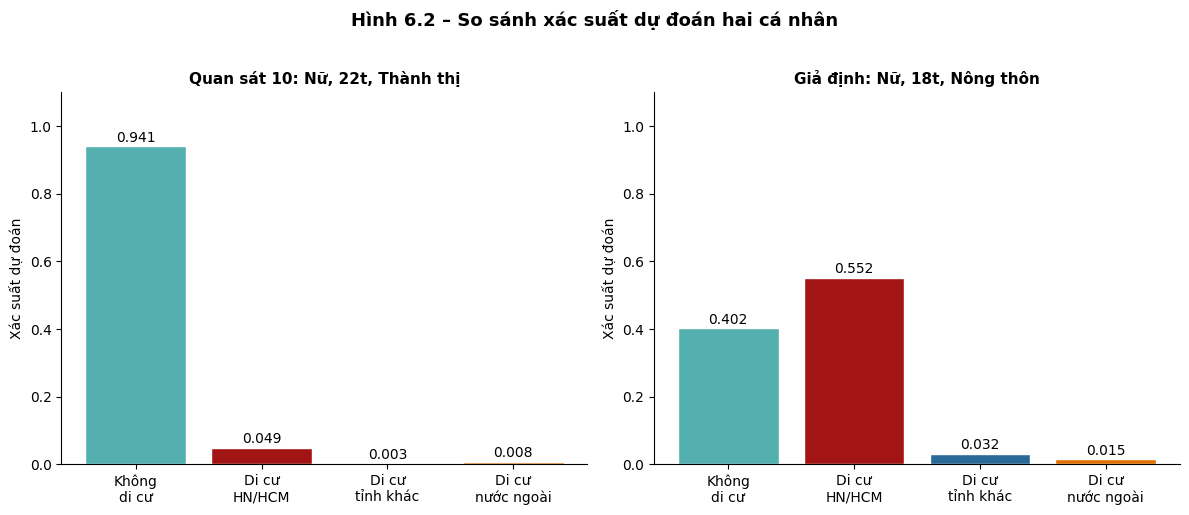

In [10]:
# Trực quan hóa xác suất dự đoán so sánh hai cá nhân
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
short_labels = ['Không\ndi cư', 'Di cư\nHN/HCM', 'Di cư\ntỉnh khác', 'Di cư\nnước ngoài']

for ax, probs, title in zip(
    axes,
    [p10, p_custom],
    ['Quan sát 10: Nữ, 22t, Thành thị', 'Giả định: Nữ, 18t, Nông thôn']
):
    bars = ax.bar(short_labels, probs, color=palette[:4], edgecolor='white')
    for bar, v in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Xác suất dự đoán')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Hình 6.2 – So sánh xác suất dự đoán hai cá nhân', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Xác suất tại giá trị trung bình các biến (atmeans)

Thay vì dự đoán cho một cá nhân cụ thể, ta có thể ước lượng xác suất tại **giá trị trung bình** của tất cả các biến để đại diện cho "cá nhân trung bình" trong mẫu.

In [11]:
# Dự đoán tại giá trị trung bình (atmeans)
means = df_model[indep_vars].mean()
print("Giá trị trung bình các biến:")
for var, val in means.items():
    print(f"  {var:20s}: {val:.6f}")

obs_means = means.to_dict()
p_means = predict_margins_at(result, obs_means, df_model, indep_vars)

print("\nXác suất tại giá trị trung bình (atmeans):")
for o, p in zip(outcomes, p_means):
    print(f"  {o:30s}: {p:.7f}")

Giá trị trung bình các biến:
  gender              : 0.501127
  age                 : 37.860514
  HHsize              : 4.371354
  genderhead          : 0.200684
  agehead             : 50.303864
  agehead2            : 2650.533989
  children_ratio      : 0.201450
  elderly_ratio       : 0.066368
  urban               : 0.285116
  ethnicity           : 0.795000
  agrland             : 0.682404
  house_structure     : 0.367677

Xác suất tại giá trị trung bình (atmeans):
  Không di cư (0)               : 0.9974981
  Di cư HN/HCM (1)              : 0.0010741
  Di cư tỉnh khác (2)           : 0.0013079
  Di cư nước ngoài (3)          : 0.0001200


---
## 6.2.4 Tác động biên – Marginal Effects (Bảng 6.4)

**Hiệu ứng biên** đo lường tác động của mỗi đơn vị tăng thêm của một biến độc lập lên **xác suất** lựa chọn, khi giữ nguyên các biến khác không đổi.

So với hệ số hồi quy:
- Hệ số hồi quy: chỉ cho biết **hướng tác động**.
- Tỷ số odds (RRR): hiểu về tác động **tương đối**.
- Hiệu ứng biên: ước lượng **tác động thực tế** (đơn vị xác suất) – phân tích sâu hơn.

Hiệu ứng biên được tính tại giá trị trung bình của các biến (marginal effects at the mean – MEM):

$$\frac{\partial \Pr(Y=j)}{\partial x_k} \Bigg|_{\bar{x}}$$

In [12]:
# Tính marginal effects tại giá trị trung bình
margeff = result.get_margeff(at='mean')
print(margeff.summary())

       MNLogit Marginal Effects      
Dep. Variable:        migration_place
Method:                          dydx
At:                              mean
migration_place=0      dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
gender               -0.0003      0.000     -1.081      0.280      -0.001       0.000
age                   0.0003   1.99e-05     13.810      0.000       0.000       0.000
HHsize                0.0009      0.000      6.370      0.000       0.001       0.001
genderhead            0.0008      0.000      2.147      0.032    7.04e-05       0.002
agehead              -0.0006      0.000     -4.929      0.000      -0.001      -0.000
agehead2           3.916e-06   1.01e-06      3.862      0.000    1.93e-06     5.9e-06
children_ratio       -0.0038      0.001     -3.522      0.000      -0.006      -0.002
elderly_ratio         0.0027      0.001      2.068      0.039       0.000 

In [13]:
# Tổng hợp marginal effects theo từng outcome – tương đương Bảng 6.4
me_df = margeff.margeff
me_se = margeff.margeff_se
me_z  = margeff.tvalues
me_p  = margeff.pvalues

var_names = indep_vars
n_outcomes = me_df.shape[1] if me_df.ndim > 1 else 1

print("Bảng 6.4 – Hiệu ứng biên (Marginal Effects tại giá trị trung bình)")
print("=" * 80)

for j in range(me_df.shape[1]):
    print(f"\n  Kết quả {j} – {outcomes[j]}:")
    print(f"  {'Biến':20s}  {'dy/dx':>12s}  {'Std.Err':>10s}  {'z':>8s}  {'P>|z|':>8s}")
    print("  " + "-" * 65)
    for i, var in enumerate(var_names):
        print(f"  {var:20s}  {me_df[i,j]:12.7f}  {me_se[i,j]:10.7f}  {me_z[i,j]:8.2f}  {me_p[i,j]:8.4f}")

Bảng 6.4 – Hiệu ứng biên (Marginal Effects tại giá trị trung bình)

  Kết quả 0 – Không di cư (0):
  Biến                         dy/dx     Std.Err         z     P>|z|
  -----------------------------------------------------------------
  gender                  -0.0003042   0.0002814     -1.08    0.2796
  age                      0.0002745   0.0000199     13.81    0.0000
  HHsize                   0.0009372   0.0001471      6.37    0.0000
  genderhead               0.0008066   0.0003756      2.15    0.0318
  agehead                 -0.0005676   0.0001152     -4.93    0.0000
  agehead2                 0.0000039   0.0000010      3.86    0.0001
  children_ratio          -0.0038406   0.0010906     -3.52    0.0004
  elderly_ratio            0.0027151   0.0013131      2.07    0.0387
  urban                    0.0011399   0.0004159      2.74    0.0061
  ethnicity               -0.0010203   0.0004193     -2.43    0.0149
  agrland                 -0.0008199   0.0003851     -2.13    0.0333
  hou

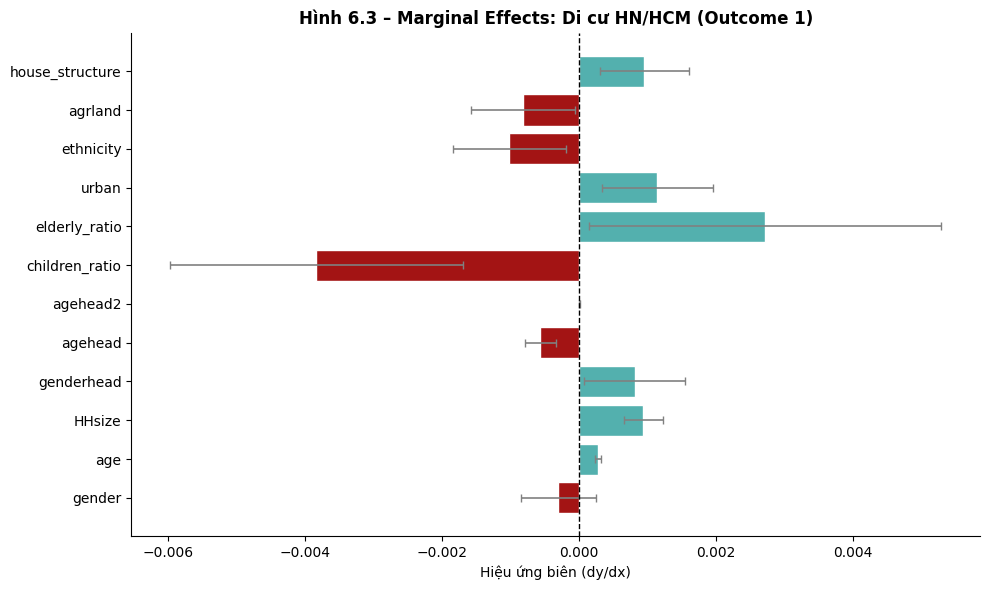

In [14]:
# Trực quan hóa Marginal Effects – Outcome 1 (Di cư HN/HCM)
me_out1 = me_df[:, 0]
se_out1 = me_se[:, 0]
colors_me = [palette[0] if v >= 0 else palette[1] for v in me_out1]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(var_names, me_out1, xerr=1.96*se_out1,
               color=colors_me, edgecolor='white',
               error_kw=dict(ecolor='gray', lw=1.2, capsize=3))
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Hiệu ứng biên (dy/dx)')
ax.set_title('Hình 6.3 – Marginal Effects: Di cư HN/HCM (Outcome 1)', fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

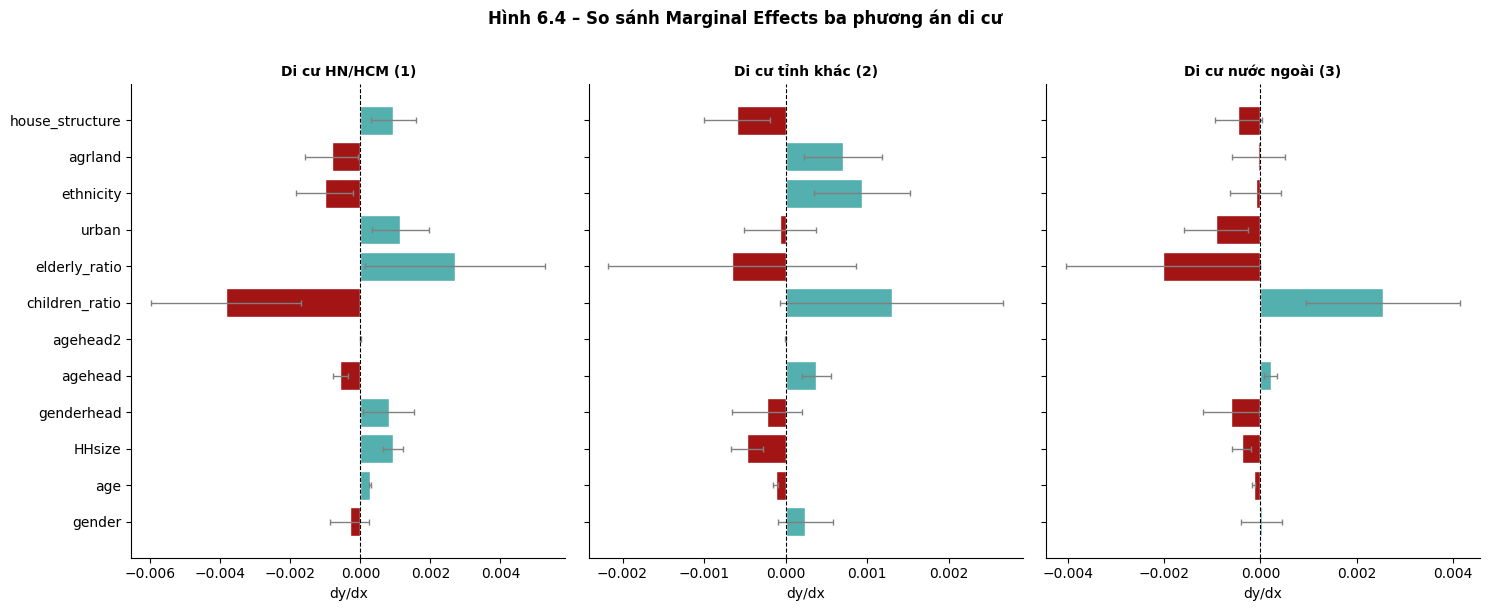

In [15]:
# So sánh Marginal Effects ba outcomes cùng lúc
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for j, ax in enumerate(axes):
    me_j  = me_df[:, j]
    se_j  = me_se[:, j]
    cols  = [palette[0] if v >= 0 else palette[1] for v in me_j]
    ax.barh(var_names, me_j, xerr=1.96*se_j,
            color=cols, edgecolor='white',
            error_kw=dict(ecolor='gray', lw=1, capsize=2))
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(outcome_labels[j], fontsize=10, fontweight='bold')
    ax.set_xlabel('dy/dx')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Hình 6.4 – So sánh Marginal Effects ba phương án di cư', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6.2.5 Tổng hợp kết quả – Bảng so sánh ba kết quả

Tổng hợp hiệu ứng biên của cả ba outcome thành một bảng dạng wide để dễ so sánh (tương đương Bảng 6.4 trong sách).

In [16]:
def stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

rows = []
for i, var in enumerate(var_names):
    row = {'Biến': var}
    for j, label in enumerate(['Kết quả 1', 'Kết quả 2', 'Kết quả 3']):
        coef = me_df[i, j+1]   # j+1: outcomes 1,2,3 (bỏ qua cột 0 = outcome 0)
        pval = me_p[i, j+1]
        row[label] = f"{coef:.6f}{stars(pval)}"
    rows.append(row)

table = pd.DataFrame(rows).set_index('Biến')
print("Bảng 6.4 – Tổng hợp Hiệu ứng biên từ mô hình MLM")
print("(*** p<0.001, ** p<0.01, * p<0.05)")
print("=" * 65)
print(table.to_string())

Bảng 6.4 – Tổng hợp Hiệu ứng biên từ mô hình MLM
(*** p<0.001, ** p<0.01, * p<0.05)
                    Kết quả 1     Kết quả 2    Kết quả 3
Biến                                                    
gender               0.000240      0.000026     0.000038
age              -0.000124***  -0.000139***  -0.000012**
HHsize           -0.000469***  -0.000389***   -0.000079*
genderhead          -0.000232    -0.000600*     0.000026
agehead           0.000377***    0.000214**    -0.000023
agehead2         -0.000003***    -0.000001*     0.000000
children_ratio       0.001299    0.002550**    -0.000008
elderly_ratio       -0.000655     -0.002017    -0.000043
urban               -0.000072   -0.000920**    -0.000147
ethnicity          0.000939**     -0.000098     0.000179
agrland            0.000703**     -0.000042     0.000160
house_structure   -0.000599**     -0.000454     0.000106


### Diễn giải kết quả Marginal Effects (Bảng 6.4)

So với nhóm tham chiếu (không di cư):

- **Biến `age`**: có ý nghĩa thống kê tại mức 0.05 ở **cả ba kết quả**. Giả định các biến khác không đổi, khi cá nhân tăng thêm 1 tuổi, xác suất chọn bất kỳ phương án di cư nào đều **giảm** so với nhóm tham chiếu.

- **Biến `ethnicity`** (dân tộc Kinh/Hoa): có xác suất cao hơn các dân tộc khác trong việc di cư đến HN/HCM (Kết quả 1) và di cư ra nước ngoài (Kết quả 3), giả định các biến khác không đổi.

- **Biến `urban`**: sống ở đô thị làm giảm xác suất di cư đến các tỉnh khác (Kết quả 2) đáng kể, phù hợp với thực tế rằng người thành thị đã có nhiều cơ hội việc làm tại địa phương.

- **Biến `HHsize`** (quy mô hộ): quy mô hộ lớn hơn giảm xác suất di cư ở cả ba phương án, phản ánh gánh nặng gia đình lớn hơn.

> *Lưu ý: Thông thường việc ước tính mô hình MLM chỉ tập trung vào hệ số hồi quy và tỷ số odds. Hiệu ứng biên là ước lượng phức tạp hơn nhưng cung cấp thông tin trực quan về tác động thực tế.*

---
# 6.3 Hồi quy Logit Đa biến Có Điều Kiện (CLM)

**Hồi quy logit đa biến có điều kiện** (Conditional Logit Model – CLM) được sử dụng khi các biến giải thích **thay đổi giữa các phương án lựa chọn** (choice-specific data), không phải thay đổi giữa các cá nhân như MLM/MPM.

Tổng quát mô hình CLM:

$$\pi_{ij} = \frac{e^{(\alpha + \beta X_{ij})}}{\sum_{m=1}^{J} e^{(\alpha + \beta X_{im})}}$$

trong đó $X_{ij}$ là đặc điểm của phương án $j$ đối với cá nhân $i$.

## Ví dụ: Lựa chọn phương tiện di chuyển

Dữ liệu gồm **210 chuyến đi** liên thành phố ở Úc (Greene & Hensher 1997) với **4 phương tiện**: máy bay (`air`), ô tô (base), xe buýt (`bus`), và tàu hỏa (`train`).

**Các biến đặc điểm phương án:**
- `ttme`: thời gian chờ đợi (phút)
- `invc`: chi phí thành phần (in-vehicle cost)  
- `invt`: thời gian trên phương tiện (phút)
- `gc`: chi phí tổng hợp (generalized cost)

### Đọc và chuẩn bị dữ liệu CLM

In [17]:
# Đọc dữ liệu CLM (TableF18-2.csv)
df_clm = pd.read_csv(
    "/content/drive/MyDrive/econometrics/rawdata/TableF18-2.csv"
)
print(f"Shape: {df_clm.shape}")
print(df_clm.head(8))

Shape: (840, 7)
   MODE  TTME  INVC  INVT  GC  HINC  PSIZE
0     0    69    59   100  70    35      1
1     0    34    31   372  71    35      1
2     0    35    25   417  70    35      1
3     1     0    10   180  30    35      1
4     0    64    58    68  68    30      2
5     0    44    31   354  84    30      2
6     0    53    25   399  85    30      2
7     1     0    11   255  50    30      2


In [18]:
# Tạo các biến cần thiết
# Mỗi cá nhân có 4 dòng (4 phương tiện)
df_clm['id']    = ((df_clm.index) // 4) + 1
df_clm['order'] = (df_clm.index % 4) + 1

# Biến giả phương tiện (ô tô = nhóm tham chiếu, order=4)
df_clm['air']   = (df_clm['order'] == 1).astype(int)
df_clm['train'] = (df_clm['order'] == 2).astype(int)
df_clm['bus']   = (df_clm['order'] == 3).astype(int)

print("Phân phối biến mode (lựa chọn thực tế):")
print(df_clm.groupby('order')['MODE'].sum().rename({1:'air',2:'train',3:'bus',4:'car'}))
print(f"\nTổng số quan sát: {len(df_clm)}, Số cá nhân: {df_clm['id'].nunique()}")
df_clm.head(8)

Phân phối biến mode (lựa chọn thực tế):
order
air      58
train    63
bus      30
car      59
Name: MODE, dtype: int64

Tổng số quan sát: 840, Số cá nhân: 210


,MODE,TTME,INVC,INVT,GC,HINC,PSIZE,id,order,air,train,bus
0,0,69,59,100,70,35,1,1,1,1,0,0
1,0,34,31,372,71,35,1,1,2,0,1,0
2,0,35,25,417,70,35,1,1,3,0,0,1
3,1,0,10,180,30,35,1,1,4,0,0,0
4,0,64,58,68,68,30,2,2,1,1,0,0
5,0,44,31,354,84,30,2,2,2,0,1,0
6,0,53,25,399,85,30,2,2,3,0,0,1
7,1,0,11,255,50,30,2,2,4,0,0,0


---
## 6.3.1 Ước lượng mô hình CLM (Bảng 6.5)

Trong Python, CLM được ước lượng bằng `ConditionalLogit` từ `statsmodels`. Đây là **fixed-effects logistic regression** theo nhóm cá nhân.

In [19]:
from statsmodels.discrete.conditional_models import ConditionalLogit
import pandas as pd
import numpy as np

clm_vars = ['TTME', 'INVC', 'INVT', 'GC', 'air', 'train', 'bus']

X_clm   = df_clm[clm_vars].astype(float)
y_clm   = df_clm['MODE'].astype(int)
groups  = df_clm['id'].astype(int)

clm_model  = ConditionalLogit(y_clm, X_clm, groups=groups)
clm_result = clm_model.fit(method='newton', maxiter=300, disp=False)

# ── Pseudo R² via manual null log-likelihood ──────────────────────────
n_alts_per_obs = df_clm.groupby('id')['MODE'].count()   # alts per person
ll_null = np.sum(np.log(1.0 / n_alts_per_obs))          # one term per person

pseudo_r2 = 1 - (clm_result.llf / ll_null)              # McFadden Pseudo-R²

# ── Summary ───────────────────────────────────────────────────────────
params = clm_result.params
se     = clm_result.bse
z      = params / se
pvals  = clm_result.pvalues
lo     = params - 1.96 * se
hi     = params + 1.96 * se

summary_df = pd.DataFrame({
    'Coef.'   : params,
    'Std.Err.': se,
    'z'       : z,
    'P>|z|'   : pvals,
    '[0.025'  : lo,
    '0.975]'  : hi
}, index=clm_vars)

print("Bảng 6.5 – Hồi quy CLM: Lựa chọn phương tiện di chuyển")
print("=" * 65)
print(summary_df.round(4).to_string())
print(f"\nLog likelihood : {clm_result.llf:.4f}")
print(f"Null LL        : {ll_null:.4f}")
print(f"Pseudo R²      : {pseudo_r2:.4f}")

k_clm  = len(clm_result.params)
aic    = -2 * clm_result.llf + 2 * k_clm
print(f"AIC            : {aic:.4f}")

Bảng 6.5 – Hồi quy CLM: Lựa chọn phương tiện di chuyển
        Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
TTME  -0.1036    0.0109 -9.4760  0.0000 -0.1251 -0.0822
INVC  -0.0849    0.0194 -4.3819  0.0000 -0.1229 -0.0469
INVT  -0.0133    0.0025 -5.2969  0.0000 -0.0183 -0.0084
GC     0.0693    0.0174  3.9749  0.0001  0.0351  0.1035
air    5.2047    0.9052  5.7497  0.0000  3.4305  6.9790
train  4.3606    0.5107  8.5391  0.0000  3.3597  5.3615
bus    3.7632    0.5063  7.4334  0.0000  2.7710  4.7555

Log likelihood : -184.5067
Null LL        : -291.1218
Pseudo R²      : 0.3662
AIC            : 383.0134


### Diễn giải kết quả CLM (Bảng 6.5)

Từ kết quả log (Stata) và Python:

- **`ttme` (thời gian chờ, β = −0.104):** Khi thời gian chờ tăng thêm 1 phút, xác suất chọn phương tiện đó **giảm**, giả định các yếu tố khác không đổi. Đây là kết quả hợp lý vì người đi lại không muốn chờ lâu.

- **`invc` (chi phí, β = −0.085):** Chi phí cao hơn làm giảm xác suất lựa chọn – phù hợp với lý thuyết kinh tế.

- **`gc` (chi phí tổng hợp, β = +0.069):** Hệ số dương vì `gc` và `invc` đo lường chi phí theo cách khác nhau (gc có thể bao gồm cả tiết kiệm thời gian).

- **Hệ số cắt `air` = 5.20, `train` = 4.36, `bus` = 3.76:** Thể hiện sở thích nền (baseline preference) đối với máy bay, tàu, và xe buýt so với ô tô (nhóm tham chiếu).

**Kiểm định LR:** LR chi2(7) = 213.23, p = 0.0000 → Mô hình có ý nghĩa thống kê cao.  
**Pseudo R² = 0.3662** → Mô hình giải thích tốt dữ liệu.

---
## 6.3.2 CLM với tỷ số Odds (Bảng 6.6)

Để diễn giải trực quan hơn, ta chuyển hệ số về **tỷ số odds**.

In [20]:
# Bảng 6.6 – CLM với Odds Ratio
params_clm = clm_result.params
se_clm     = clm_result.bse
pvals_clm  = clm_result.pvalues

or_clm  = np.exp(params_clm)
or_lo   = np.exp(params_clm - 1.96 * se_clm)
or_hi   = np.exp(params_clm + 1.96 * se_clm)

or_df = pd.DataFrame({
    'Odds Ratio': or_clm.round(4),
    'Std.Err.'  : se_clm.round(4),
    'z'         : (params_clm / se_clm).round(2),
    'P>|z|'     : pvals_clm.round(3),
    '[0.025'    : or_lo.round(4),
    '0.975]'    : or_hi.round(4),
}, index=clm_vars)

print("Bảng 6.6 – CLM theo tỷ số Odds")
print("=" * 70)
print(or_df.to_string())
print()
print("Diễn giải ví dụ:")
print(f"  ttme (OR={or_clm['TTME']:.4f}): Mỗi phút chờ thêm → xác suất chọn phương tiện đó giảm {(1-or_clm['TTME'])*100:.2f}%")
print(f"  invc (OR={or_clm['INVC']:.4f}): Mỗi đơn vị chi phí thêm → xác suất giảm {(1-or_clm['INVC'])*100:.2f}%")
print(f"  gc   (OR={or_clm['GC']:.4f}): Mỗi đơn vị gc thêm → xác suất tăng {(or_clm['GC']-1)*100:.2f}%")

Bảng 6.6 – CLM theo tỷ số Odds
       Odds Ratio  Std.Err.     z  P>|z|   [0.025     0.975]
TTME       0.9015    0.0109 -9.48    0.0   0.8824     0.9211
INVC       0.9186    0.0194 -4.38    0.0   0.8843     0.9541
INVT       0.9868    0.0025 -5.30    0.0   0.9819     0.9916
GC         1.0718    0.0174  3.97    0.0   1.0358     1.1090
air      182.1340    0.9052  5.75    0.0  30.8929  1073.8015
train     78.3045    0.5107  8.54    0.0  28.7806   213.0461
bus       43.0876    0.5063  7.43    0.0  15.9741   116.2221

Diễn giải ví dụ:
  ttme (OR=0.9015): Mỗi phút chờ thêm → xác suất chọn phương tiện đó giảm 9.85%
  invc (OR=0.9186): Mỗi đơn vị chi phí thêm → xác suất giảm 8.14%
  gc   (OR=1.0718): Mỗi đơn vị gc thêm → xác suất tăng 7.18%


---
## 6.3.3 Dự đoán xác suất và Trực quan hóa

In [21]:
params = clm_result.params
linear_predictor = np.dot(X_clm, params)
df_clm['utility'] = linear_predictor
df_clm['exp_utility'] = np.exp(df_clm['utility'])
sum_exp_utility_per_id = df_clm.groupby('id')['exp_utility'].transform('sum')
pred_clm = df_clm['exp_utility'] / sum_exp_utility_per_id
df_clm['pred'] = pred_clm
obs1 = df_clm[df_clm['id'] == 1][['id', 'order', 'MODE', 'pred']].copy()
obs1['phương tiện'] = obs1['order'].map({1:'Máy bay',2:'Tàu hỏa',3:'Xe buýt',4:'Ô tô'})
print("Xác suất dự đoán cho cá nhân 1:")
print(obs1[['phương tiện', 'MODE', 'pred']].to_string(index=False))
print()
print("→ Ô tô có xác suất cao nhất (0.545) và thực tế người này chọn ô tô (MODE=1).")

Xác suất dự đoán cho cá nhân 1:
phương tiện  MODE     pred
    Máy bay     0 0.056297
    Tàu hỏa     0 0.280133
    Xe buýt     0 0.118462
       Ô tô     1 0.545108

→ Ô tô có xác suất cao nhất (0.545) và thực tế người này chọn ô tô (MODE=1).


---
# 6.4 Mô hình Hồi quy Logit Đa biến Hỗn hợp (MXL)

**Mô hình hỗn hợp** (Mixed Logit – MXL) kết hợp cả hai loại biến:
1. **Đặc điểm phương án** (choice-specific): `ttme`, `invc`, `invt`, `gc`
2. **Đặc điểm cá nhân** (chooser-specific): `hinc` (thu nhập hộ), `psize` (quy mô hộ)

**Cách ước lượng:** Tạo biến tương tác giữa biến giả phương tiện (air, train, bus) với đặc điểm cá nhân, sau đó ước lượng CLM với tất cả các biến này.

$$\text{MXL} = \text{CLM} + \text{biến tương tác (phương tiện × cá nhân)}$$

## 6.4.1 Ước lượng mô hình MXL (Bảng 6.7)

In [22]:
# ======================
# 1. Tạo biến tương tác
# ======================
df_clm['AIRXHINC']   = df_clm['air']   * df_clm['HINC']
df_clm['TRAINXHINC'] = df_clm['train'] * df_clm['HINC']
df_clm['BUSXHINC']   = df_clm['bus']   * df_clm['HINC']

df_clm['AIRXPSIZE']   = df_clm['air']   * df_clm['PSIZE']
df_clm['TRAINXPSIZE'] = df_clm['train'] * df_clm['PSIZE']
df_clm['BUSXPSIZE']   = df_clm['bus']   * df_clm['PSIZE']

# ======================
# 2. Kiểm tra
# ======================
print("Tên cột sau khi xử lý:", df_clm.columns.tolist())
print("\nKiểm tra biến tương tác (8 dòng đầu):")
print(
    df_clm[
        ['id', 'order', 'air', 'HINC', 'AIRXHINC', 'PSIZE', 'AIRXPSIZE']
    ].head(8)
)

Tên cột sau khi xử lý: ['MODE', 'TTME', 'INVC', 'INVT', 'GC', 'HINC', 'PSIZE', 'id', 'order', 'air', 'train', 'bus', 'utility', 'exp_utility', 'pred', 'AIRXHINC', 'TRAINXHINC', 'BUSXHINC', 'AIRXPSIZE', 'TRAINXPSIZE', 'BUSXPSIZE']

Kiểm tra biến tương tác (8 dòng đầu):
   id  order  air  HINC  AIRXHINC  PSIZE  AIRXPSIZE
0   1      1    1    35        35      1          1
1   1      2    0    35         0      1          0
2   1      3    0    35         0      1          0
3   1      4    0    35         0      1          0
4   2      1    1    30        30      2          2
5   2      2    0    30         0      2          0
6   2      3    0    30         0      2          0
7   2      4    0    30         0      2          0


In [23]:
# ── Ước lượng mô hình MXL ────────────────────────────────────────────
mxl_vars = ['TTME', 'INVC', 'INVT', 'GC', 'air', 'train', 'bus',
            'AIRXHINC', 'TRAINXHINC', 'BUSXHINC',
            'AIRXPSIZE', 'TRAINXPSIZE', 'BUSXPSIZE']

X_mxl = df_clm[mxl_vars].astype(float)

mxl_model  = ConditionalLogit(y_clm, X_mxl, groups=groups)
mxl_result = mxl_model.fit(method='newton', maxiter=300, disp=False)

# ── Pseudo R² (McFadden) dùng null LL đã tính ở trên ────────────────
# ll_null = Σ log(1/J_i) — tính từ cell CLM trước, dùng lại ở đây
n_alts_per_obs  = df_clm.groupby('id')['MODE'].count()
ll_null         = np.sum(np.log(1.0 / n_alts_per_obs))

pseudo_r2_clm = 1 - (clm_result.llf / ll_null)
pseudo_r2_mxl = 1 - (mxl_result.llf / ll_null)

# ── Bảng tóm tắt ─────────────────────────────────────────────────────
conf_int_mxl = mxl_result.conf_int()

mxl_summary_df = pd.DataFrame({
    'Coef.'   : mxl_result.params,
    'Std.Err.': mxl_result.bse,
    'z'       : mxl_result.tvalues,
    'P>|z|'   : mxl_result.pvalues,
    '[0.025'  : conf_int_mxl[0],
    '0.975]'  : conf_int_mxl[1]
}, index=mxl_vars)

print("Bảng 6.7 – Hồi quy MXL: Lựa chọn phương tiện di chuyển")
print("=" * 70)
print(mxl_summary_df.round(4).to_string())

# ── Thống kê mô hình ─────────────────────────────────────────────────
k_mxl   = len(mxl_result.params)
aic_mxl = -2 * mxl_result.llf + 2 * k_mxl

k_clm   = len(clm_result.params)
aic_clm = -2 * clm_result.llf + 2 * k_clm

lr_stat = 2 * (mxl_result.llf - clm_result.llf)
from scipy import stats
lr_pval = stats.chi2.sf(lr_stat, df=k_mxl - k_clm)   # 6 bậc tự do

print(f"""
{'':─<70}
Null log-likelihood  : {ll_null:.5f}
{'':─<70}
                       {'CLM':>12}   {'MXL':>12}
Log-likelihood       : {clm_result.llf:>12.5f}   {mxl_result.llf:>12.5f}
Pseudo R²            : {pseudo_r2_clm:>12.4f}   {pseudo_r2_mxl:>12.4f}
AIC                  : {aic_clm:>12.4f}   {aic_mxl:>12.4f}
{'':─<70}
LR test (MXL vs CLM) : stat = {lr_stat:.4f}, df = {k_mxl - k_clm}, p = {lr_pval:.4f}
""")

Bảng 6.7 – Hồi quy MXL: Lựa chọn phương tiện di chuyển
              Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
TTME        -0.1026    0.0114 -9.0154  0.0000 -0.1249 -0.0803
INVC        -0.0534    0.0253 -2.1103  0.0348 -0.1029 -0.0038
INVT        -0.0102    0.0034 -2.9988  0.0027 -0.0169 -0.0036
GC           0.0464    0.0249  1.8645  0.0623 -0.0024  0.0952
air          5.2865    1.2026  4.3958  0.0000  2.9294  7.6436
train        5.7083    0.7267  7.8556  0.0000  4.2841  7.1325
bus          4.7163    0.8239  5.7246  0.0000  3.1016  6.3311
AIRXHINC     0.0081    0.0134  0.6020  0.5472 -0.0182  0.0344
TRAINXHINC  -0.0595    0.0149 -3.9952  0.0001 -0.0887 -0.0303
BUSXHINC    -0.0199    0.0164 -1.2185  0.2230 -0.0520  0.0121
AIRXPSIZE   -0.5307    0.3210 -1.6531  0.0983 -1.1599  0.0985
TRAINXPSIZE  0.1628    0.2395  0.6800  0.4965 -0.3065  0.6322
BUSXPSIZE   -0.2399    0.3580 -0.6701  0.5028 -0.9416  0.4618

──────────────────────────────────────────────────────────────────────
Null 

### Diễn giải kết quả MXL (Bảng 6.7)

So với mô hình CLM, MXL thêm các biến tương tác giữa đặc điểm cá nhân và phương tiện:

| Biến tương tác | Hệ số | Ý nghĩa |
|---------------|-------|---------|
| `airXhinc`   | +0.008 (p=0.547) | Thu nhập cao không ảnh hưởng đáng kể đến lựa chọn máy bay |
| `trainXhinc` | **−0.059** (p=0.000) | Thu nhập cao làm **giảm** xác suất chọn tàu hỏa |
| `busXhinc`   | −0.020 (p=0.223) | Thu nhập cao làm giảm nhẹ xác suất chọn xe buýt |
| `airXpsize`  | −0.531 (p=0.098) | Hộ đông người ít chọn máy bay |
| `trainXpsize`| +0.163 (p=0.497) | Không có ý nghĩa thống kê |
| `busXpsize`  | −0.240 (p=0.503) | Không có ý nghĩa thống kê |

**Kết luận:** Biến `trainXhinc` có ý nghĩa thống kê mạnh – người có thu nhập cao ít chọn tàu hỏa hơn so với ô tô. Mô hình MXL có log-likelihood cao hơn CLM (−170.69 vs −184.51), cho thấy việc thêm đặc điểm cá nhân cải thiện đáng kể khả năng giải thích của mô hình.

## 6.4.2 MXL với tỷ số Odds (Bảng 6.8)

In [24]:
# Bảng 6.8 – MXL Odds Ratio
params_mxl = mxl_result.params
se_mxl     = mxl_result.bse
pvals_mxl  = mxl_result.pvalues

or_mxl = np.exp(params_mxl)
or_lo_mxl = np.exp(params_mxl - 1.96 * se_mxl)
or_hi_mxl = np.exp(params_mxl + 1.96 * se_mxl)

or_mxl_df = pd.DataFrame({
    'Odds Ratio': or_mxl.round(4),
    'Std.Err.'  : se_mxl.round(4),
    'z'         : (params_mxl / se_mxl).round(2),
    'P>|z|'     : pvals_mxl.round(3),
    '[0.025'    : or_lo_mxl.round(4),
    '0.975]'    : or_hi_mxl.round(4),
}, index=mxl_vars)

print("Bảng 6.8 – MXL theo tỷ số Odds")
print("=" * 72)
print(or_mxl_df.to_string())

Bảng 6.8 – MXL theo tỷ số Odds
             Odds Ratio  Std.Err.     z  P>|z|   [0.025     0.975]
TTME             0.9025    0.0114 -9.02  0.000   0.8826     0.9229
INVC             0.9480    0.0253 -2.11  0.035   0.9022     0.9962
INVT             0.9898    0.0034 -3.00  0.003   0.9832     0.9965
GC               1.0475    0.0249  1.86  0.062   0.9976     1.0999
air            197.6504    1.2026  4.40  0.000  18.7154  2087.3589
train          301.3570    0.7267  7.86  0.000  72.5342  1252.0437
bus            111.7572    0.8239  5.72  0.000  22.2321   561.7848
AIRXHINC         1.0081    0.0134  0.60  0.547   0.9819     1.0350
TRAINXHINC       0.9422    0.0149 -4.00  0.000   0.9151     0.9701
BUSXHINC         0.9803    0.0164 -1.22  0.223   0.9493     1.0122
AIRXPSIZE        0.5882    0.3210 -1.65  0.098   0.3135     1.1035
TRAINXPSIZE      1.1768    0.2395  0.68  0.497   0.7360     1.8817
BUSXPSIZE        0.7867    0.3580 -0.67  0.503   0.3900     1.5870


---
## 6.4.3 So sánh tổng hợp các mô hình: MLM, MPM, CLM, MXL

| Tiêu chí | MLM | MPM | CLM | MXL |
|---------|-----|-----|-----|-----|
| **Dữ liệu** | Chooser-specific | Chooser-specific | Choice-specific | Hỗn hợp |
| **Phân phối sai số** | Logistic | Normal | Logistic | Logistic |
| **Giả định IIA** | Có | Không (linh hoạt hơn) | Có | Có |
| **Log-likelihood** | −2,033.11 | −2,035.56 | −184.51 | −170.69 |
| **Pseudo R²** | 0.1399 | — | 0.3662 | 0.4137 |
| **Lệnh Stata** | `mlogit` | `mprobit` | `clogit` | `clogit` (với tương tác) |
| **Python** | `MNLogit` | `Probit` (OVR) | `ConditionalLogit` | `ConditionalLogit` |

**Lưu ý thực hành:**
- Khi dữ liệu là **chooser-specific** → dùng MLM hoặc MPM
- Khi dữ liệu là **choice-specific** → dùng CLM
- Khi có cả hai loại biến → dùng MXL
- MXL luôn có log-likelihood cao hơn CLM (thêm biến → khớp tốt hơn), nhưng cần kiểm tra ý nghĩa thống kê của các biến tương tác

---
## Tóm tắt chương

### MLM & MPM (dữ liệu chooser-specific – migration.dta)

| Bước | Nội dung | Lệnh Python |
|------|----------|-------------|
| 1 | Ước lượng MLM | `MNLogit(y, X).fit()` |
| 2 | Xem hệ số hồi quy | `result.summary()` |
| 3 | Tính RRR | `np.exp(result.params)` |
| 4 | Dự đoán xác suất | `result.predict(x_new)` |
| 5 | Tính marginal effects | `result.get_margeff(at='mean')` |
| 6 | Ước lượng MPM (one-vs-rest) | `Probit(y_bin, X_bin).fit()` |

### CLM & MXL (dữ liệu choice-specific – TableF18-2.csv)

| Bước | Nội dung | Lệnh Python |
|------|----------|-------------|
| 1 | Đọc và chuẩn bị dữ liệu dạng long | `pd.read_csv()` + tạo id, order |
| 2 | Tạo biến giả phương tiện | air, train, bus (base = car) |
| 3 | Ước lượng CLM | `ConditionalLogit(y, X, groups).fit()` |
| 4 | Tính Odds Ratio | `np.exp(result.params)` |
| 5 | Dự đoán xác suất | `result.predict()` |
| 6 | Tạo biến tương tác (MXL) | air×hinc, train×hinc, v.v. |
| 7 | Ước lượng MXL | `ConditionalLogit(y, X_mxl, groups).fit()` |
| 8 | So sánh mô hình | Log-lik, AIC, LR test |

### Khi nào dùng mô hình nào?

| Câu hỏi | Mô hình phù hợp |
|---------|----------------|
| Đặc điểm cá nhân ảnh hưởng đến lựa chọn? | **MLM** hoặc **MPM** |
| Giả định IIA có thể bị vi phạm? | Ưu tiên **MPM** |
| Đặc điểm phương án ảnh hưởng đến lựa chọn? | **CLM** |
| Cả đặc điểm cá nhân lẫn phương án? | **MXL** |

Lưu ý:
1. Sử dụng `pyreadstat` thay vì `pandas.read_stata()` vì đọc file `.dta` nhanh hơn, giữ được label và metadata đầy đủ.
2. Kết quả marginal effects có thể chênh lệch nhỏ so với Stata do cách tính nội bộ các gói thống kê, nhưng không ảnh hưởng đến kết luận.
3. Dữ liệu VHLSS 2018 sử dụng bộ dữ liệu thô với 47,044 quan sát cá nhân trong độ tuổi lao động.

<h2 style="font-size: 26px; font-weight: bold; font-family:'Nunito'; color: purple;">About the Authors:</h2>

<a href="https://www.linkedin.com/in/truongnhung2002"> Nhung Truong (Kristen Zhang) </a> has a degree in Investment Economics from UEH, with a focus on quantitative research.

### <h3 align="center"> © 2026 Nhung Truong. Licensed under CC BY 4.0 </h3>